# Forest Fire Progression — Sentinel-2 / Sentinel-1 Data Fusion

This notebook converts the Sentinel Hub
[S2/S1 Forest Fire Progression](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/s2_s1_forest_fire_progression/)
evalscript by **Max Kampen** into a reusable openEO User-Defined Process (UDP).

## Overview

This is a **multi-sensor, multi-temporal data-fusion** algorithm. Optical imagery
is often useless during an active wildfire because smoke and clouds hide the
ground, but Sentinel-1 SAR penetrates clouds. The script therefore combines:

1. **Sentinel-2 (optical) at t1** — maps the pre/early-fire vegetation and burned
   area from spectral indices.
2. **Sentinel-1 (SAR) at t1 and t2** — the change in VH backscatter between the two
   dates reveals where the fire *progressed* in the days after t1, even under cloud.

Using the September 2019 fires on the **Bolivia/Paraguay border** (the Chiquitano
dry forest) as the worked example, with Sentinel data from **7 September (t1)** and
**12 September (t2)** 2019.

## What the classification produces

For each pixel the original returns one of four states:

| Colour | Meaning | Condition |
| --- | --- | --- |
| **Red** | newly burned (fire progressed here after t1) | vegetated/unburned in S2 t1, **and** S1 t2 shows a burn drop (`VH(t2) < 0.03` and `VH(t2)-VH(t1) < -0.015`) |
| **SWIR composite** `[2.5·B12, 2.5·B08, 2.5·B04]` | still-vegetated background | vegetated in S2 t1 but no S1 burn signal |
| **Light yellow** | already burned, still bare at t2 | non-vegetated in S2 t1 and `VV(t2) < 0.2` |
| **Blue** | already burned, recovering at t2 | non-vegetated in S2 t1 and `VV(t2) ≥ 0.2` |

### How the conversion maps to openEO

| Original (evalscript) | openEO conversion |
| --- | --- |
| three `datasource`s (`s1_t1`, `s1_t2`, `l2a_t1`) | three `load_collection` calls, each reduced to one temporal slice |
| `index(a, b)` = `(a-b)/(a+b)` | explicit band math |
| per-pixel `if/else` colour logic | nested `if_` inside one `apply_dimension` over the bands dimension |
| reading two S1 dates from one fused sample | unique band labels via `add_dimension` (CDSE lacks `rename_labels`) + `merge_cubes` |
| different S1/S2 grids | `resample_cube_spatial` of S1 onto the S2 grid before merging |

## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/s2_s1_forest_fire_progression/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)

The optical burned-area visualization reuses the "Burned Area Visualization" index
by Monja Sebela; the SAR backscatter-difference method follows Belenguer-Plomer et
al. (2019).

## Import Required Libraries

In [1]:
from openeo.processes import if_, and_, or_, array_create

import rioxarray
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

We connect to the **Copernicus Data Space Ecosystem (CDSE)**, the backend that
serves both Sentinel-1 GRD and Sentinel-2 L2A — both are required for the fusion.

In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "s2_s1_forest_fire_progression"

# Initialize parameter manager
param_manager = ParameterManager('s2_s1_forest_fire_progression.params.py')

# Display available options using the built-in helper
param_manager.print_options("forest fire progression (S2/S1 fusion) algorithm")

Available parameter sets for forest fire progression (S2/S1 fusion) algorithm:
  1. chiquitania_bolivia_2019: Chiquitania, Bolivia (2019 fires)
  2. chaco_paraguay_border_2019: Chaco, Paraguay/Bolivia border (2019 fires)
  3. aude_corbieres_france_2025: Corbières, Aude, France (2025 fire)

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# This data-fusion algorithm needs a backend that serves BOTH Sentinel-1 GRD
# and Sentinel-2 L2A. Keep the endpoint name in a variable so the Sentinel-1
# collection/bands can be mapped through the SAME endpoint mapper below.
endpoint_name = "copernicus_dataspace"
connection, current_params = param_manager.quick_connect(
    param_set="aude_corbieres_france_2025",
    endpoint=endpoint_name,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: aude_corbieres_france_2025
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Corbières, Aude, France (2025 fire)
🔄 Parameters mapped for endpoint copernicus_dataspace:
  bands: ['b03', 'b04', 'b08', 'b11', 'b12'] -> ['B03', 'B04', 'B08', 'B11', 'B12']
  collection: sentinel-2-l2a -> SENTINEL2_L2A


## Load the Three Acquisitions

The algorithm fuses three acquisitions. The **Sentinel-2** collection/bands flow
through the standard parameter mapping (so `reflectance_scale` and the dimension
names are injected); the **Sentinel-1** collection/bands are loaded explicitly.

- **S2 at t1** — `B03, B04, B08, B11, B12` for the optical indices.
- **S1 at t1** — `VH` (the baseline backscatter).
- **S1 at t2** — `VV, VH` (later backscatter; `VH` for the burn-change test, `VV`
  for the already-burned recovery test).

`bounding_box` is wired as a `Parameter` ref so the exported graph stays reusable.
Each cube is reduced over time with `mean` to collapse its short window to a single
slice.

In [4]:
bbox = current_params["bounding_box"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]

# --- Sentinel-2 optical at t1 ---
s2_t1 = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=current_params["time_t1"],
    spatial_extent=bbox,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
).reduce_dimension(dimension=time_dim, reducer="mean")

# --- Sentinel-1 SAR at t1 and t2 ---
# The standard mapping only auto-maps the single "collection"/"bands" pair used by
# Sentinel-2 above. Route the Sentinel-1 collection + polarizations through the
# SAME endpoint mapper so the canonical "sentinel-1-grd"/"vh"/"vv" resolve to this
# backend's native names (e.g. SENTINEL1_GRD/VH on CDSE, sentinel-1-grd/vh on dev).
_s1_t1 = param_manager.apply_endpoint_mapping(
    {"collection": current_params["s1_collection"], "bands": current_params["s1_bands_t1"]},
    endpoint_name,
)
_s1_t2 = param_manager.apply_endpoint_mapping(
    {"collection": current_params["s1_collection"], "bands": current_params["s1_bands_t2"]},
    endpoint_name,
)
s1_collection = _s1_t1["collection"].default

s1_t1 = connection.load_collection(
    s1_collection,
    temporal_extent=current_params["time_t1"],
    spatial_extent=bbox,
    bands=_s1_t1["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="mean")

s1_t2 = connection.load_collection(
    s1_collection,
    temporal_extent=current_params["time_t2"],
    spatial_extent=bbox,
    bands=_s1_t2["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="mean")

print("✅ Loaded S2 t1, S1 t1 and S1 t2")

✅ Loaded S2 t1, S1 t1 and S1 t2


## Fuse the Sensors into One Cube

To evaluate the per-pixel logic we need all the inputs on a single cube. Two SAR
acquisitions both carry a `VH` band, which would collide on merge — and CDSE does
not expose `rename_labels`. We therefore drop each S1 band to a bandless cube with
`.band(...)` and re-attach a **uniquely named** band dimension with
`add_dimension`. The S1 cube is then `resample_cube_spatial`-aligned onto the S2
grid and merged with the optical bands.

In [5]:
# S1 native band names vary by backend ("VH" on CDSE, "vh" on dev), so resolve
# them by prefix from each cube's metadata.
def _band(cube, prefix):
    return next(b for b in cube.metadata.band_names if b.lower().startswith(prefix))


# Give each S1 acquisition/polarization a unique band label via add_dimension
# (band() drops the bands dimension; add_dimension re-adds it with our label).
vh_t1 = s1_t1.band(_band(s1_t1, "vh")).add_dimension(name=bands_dim, label="vh_t1", type="bands")
vh_t2 = s1_t2.band(_band(s1_t2, "vh")).add_dimension(name=bands_dim, label="vh_t2", type="bands")
vv_t2 = s1_t2.band(_band(s1_t2, "vv")).add_dimension(name=bands_dim, label="vv_t2", type="bands")

# Combine the three S1 bands, align to the S2 grid, then merge with the optical cube.
s1_all = vh_t1.merge_cubes(vh_t2).merge_cubes(vv_t2)
s1_all = s1_all.resample_cube_spatial(s2_t1, method="near")

fused = s2_t1.merge_cubes(s1_all)

# The classification reads bands positionally; the order is fixed by construction:
# the 5 Sentinel-2 bands (load order) followed by vh_t1, vh_t2, vv_t2.
fused_bands = fused.metadata.band_names
print("Fused band order:", fused_bands)
assert len(fused_bands) == 8, f"expected 8 fused bands, got {fused_bands}"

Fused band order: ['B03', 'B04', 'B08', 'B11', 'B12', 'vh_t1', 'vh_t2', 'vv_t2']


## Per-Pixel Classification

A single `apply_dimension` over the bands dimension runs the original
`evaluatePixel` logic. The callback receives the 8 fused band values (in
`EXPECTED_BANDS` order) and returns the 3-element `[R, G, B]` output.

Faithful to the original:

- `index(a, b) = (a - b) / (a + b)`, so `NDWI = index(B03, B08)`,
  `NDVI = index(B08, B04)`, and `INDEX = index(B11, B12) + B08`.
- Sentinel-2 reflectance is divided by `reflectance_scale` (10000 on CDSE) to match
  the original's 0-1 input range; Sentinel-1 backscatter is used as-is (linear).
- The nested `if/else` becomes nested `if_(...)`. The four output states are
  mutually exclusive, exactly as in the evalscript.

In [6]:
scale = current_params["reflectance_scale"]  # 10000.0 on CDSE

# Original classification thresholds.
THR_VH = 0.03        # S1 t2 VH below this == bare/burned
THR_VH_DIFF = -0.015 # drop in VH from t1 to t2 == newly burned
THR_VV = 0.2         # S1 t2 VV below this == still bare/burned
THR_NDWI, THR_NDVI, THR_INDEX = 0.15, 0.35, 0.2


def classify(data):
    # Bands in fused order (5 S2 bands, then vh_t1/vh_t2/vv_t2).
    # S2 -> reflectance; S1 -> raw backscatter.
    b03 = data[0] / scale
    b04 = data[1] / scale
    b08 = data[2] / scale
    b11 = data[3] / scale
    b12 = data[4] / scale
    vh_1 = data[5]
    vh_2 = data[6]
    vv_2 = data[7]

    # Optical "burned area visualization" indices (Monja Sebela).
    ndwi = (b03 - b08) / (b03 + b08)
    ndvi = (b08 - b04) / (b08 + b04)
    index = (b11 - b12) / (b11 + b12) + b08

    # S1 VH backscatter change t1 -> t2 (Belenguer-Plomer et al. 2019).
    vh_diff = vh_2 - vh_1

    # Pixel still looks vegetated / unburned in the S2 (t1) image.
    vegetated = or_(or_(ndwi > THR_NDWI, ndvi > THR_NDVI), index > THR_INDEX)
    # ...but the SAR pair shows a fresh burn between t1 and t2.
    newly_burned = and_(vh_2 < THR_VH, vh_diff < THR_VH_DIFF)
    # Already-burned ground that is still bare at t2 (vs. recovering).
    still_burned = vv_2 < THR_VV

    # Red = newly burned; else SWIR composite background.
    veg_r = if_(newly_burned, 1.0, 2.5 * b12)
    veg_g = if_(newly_burned, 0.0, 2.5 * b08)
    veg_b = if_(newly_burned, 0.0, 2.5 * b04)
    # Light yellow = still burned; else blue = recovered.
    burn_r = if_(still_burned, 0.9, 0.0)
    burn_g = if_(still_burned, 0.9, 0.0)
    burn_b = if_(still_burned, 0.7, 1.0)

    red = if_(vegetated, veg_r, burn_r)
    green = if_(vegetated, veg_g, burn_g)
    blue = if_(vegetated, veg_b, burn_b)
    return array_create([red, green, blue])


rgb = fused.apply_dimension(dimension=bands_dim, process=classify)

## Apply and Export

Save the 3-band classification/visualization as a GeoTIFF.

In [7]:
fire_result = rgb.save_result("GTiff")

## Download and Visualize Results

Download the composite and display it. The output mixes a continuous SWIR
background with the three flat classification colours (red / light-yellow / blue),
so we render it directly as an RGB image.

In [8]:
# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialize them with the current parameter set's defaults before download.
filename = f"{_algorithm_id}_{current_params['location_name'].replace(' ', '_').replace(',', '').replace('/', '-').replace('(', '').replace(')', '').lower()}.tif"

resolved = param_manager.resolve(fire_result, current_params)
resolved.download(filename)

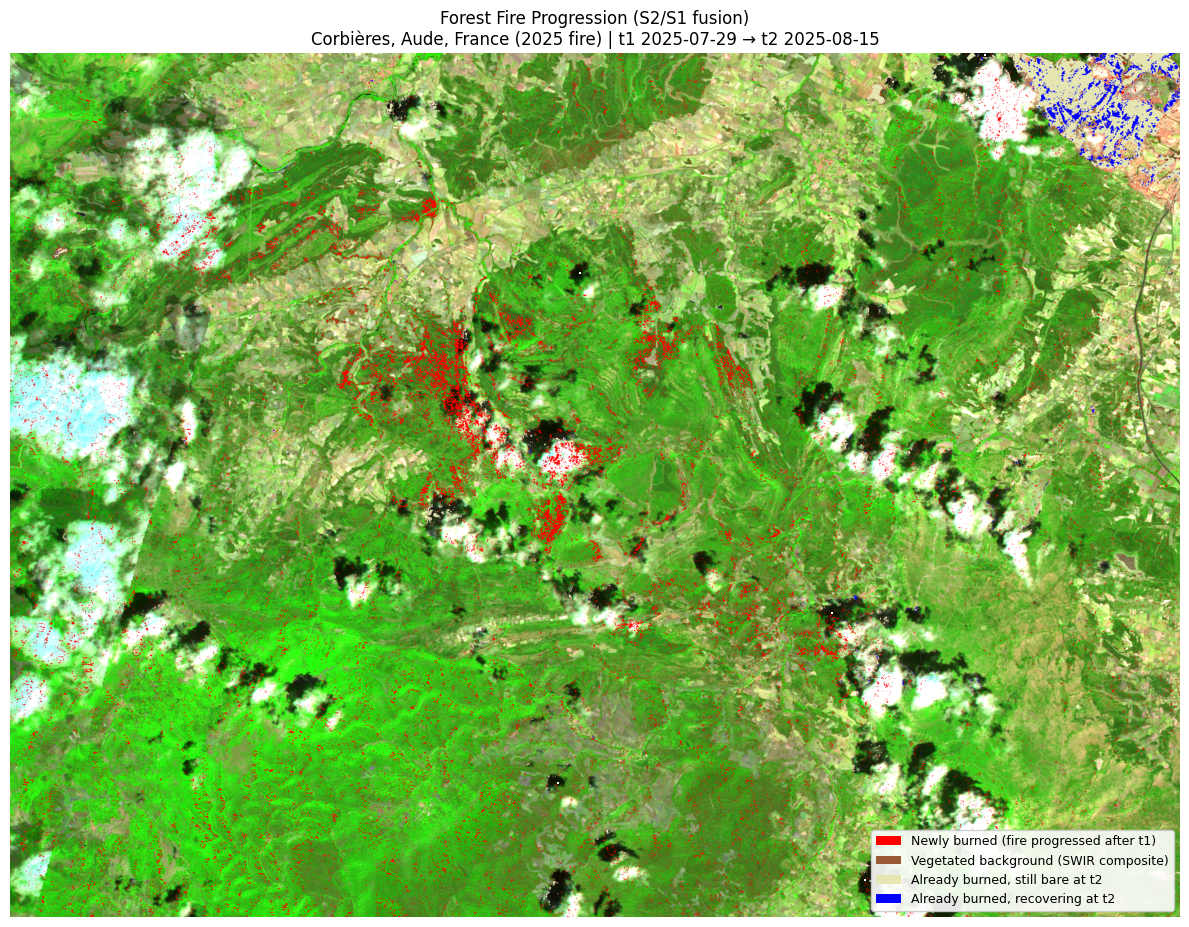

In [9]:
# Open the 3-band result and display it as an RGB image.
ds = rioxarray.open_rasterio(filename)

rgb_img = ds.transpose("y", "x", "band").values.astype("float32")
rgb_img = np.clip(rgb_img, 0, 1)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(
    rgb_img,
    extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()],
)
ax.set_title(
    f"Forest Fire Progression (S2/S1 fusion)\n{current_params['location_name']} | "
    f"t1 {current_params['time_t1'].default[0]} → t2 {current_params['time_t2'].default[1]}",
    fontsize=12,
)

legend = [
    Patch(facecolor=(1, 0, 0), label="Newly burned (fire progressed after t1)"),
    Patch(facecolor=(0.6, 0.35, 0.2), label="Vegetated background (SWIR composite)"),
    Patch(facecolor=(0.9, 0.9, 0.7), label="Already burned, still bare at t2"),
    Patch(facecolor=(0, 0, 1), label="Already burned, recovering at t2"),
]
ax.legend(handles=legend, loc="lower right", fontsize=9, framealpha=0.9)
ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation Guide and Limitations

### Reading the result

- **Red** pixels are the key output: ground that still looked vegetated on 7 Sep but
  burned in the following days, captured by Sentinel-1 through the smoke/cloud.
- The **brown/green SWIR composite** is unburned forest and provides context.
- **Light-yellow** vs **blue** distinguishes older burn scars that are still bare
  from those whose SAR signal has recovered by t2.

### Limitations and differences from the original

- **CDSE-only.** The fusion needs both Sentinel-1 GRD and Sentinel-2 L2A; CDSE is the
  backend that serves both. The S1 collection/bands are loaded with CDSE-native
  names rather than through the canonical mapper.
- **Backscatter convention.** Sentinel-1 GRD on CDSE is loaded as linear backscatter,
  matching the original's linear thresholds (`0.03`, `0.2`). If a backend returns dB
  or a different coefficient, the thresholds would need rescaling.
- **Temporal windows reduced with `mean`.** Each short window is collapsed to one
  slice; pick windows that bracket a single pass per sensor so the mean is one
  acquisition. The windows are baked into the graph; `bounding_box` stays the runtime
  knob.
- **No SCL masking.** Like the original, the S2 t1 image is assumed cloud-free; the
  whole point of the SAR fusion is to cover the cloudy t2 date.
- **Grid alignment.** S1 is resampled onto the S2 grid with nearest-neighbour before
  merging; minor co-registration differences between sensors are not corrected.

In [ ]:
# Create a directory to export images, UDP, and OGC API records
from pathlib import Path

_repo_root = next(p for p in Path.cwd().parents if (p / "notebooks").exists())
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"
_udp_dir = _alg_dir / "openeo_udp"

_records_dir.mkdir(parents=True, exist_ok=True)
_udp_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# Export the process graph for reuse as a parameterized UDP
import json

process_graph = {
    "process_graph": fire_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time_t1"].to_dict(),
        current_params["time_t2"].to_dict(),
        current_params["cloud_cover"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Multitemporal Sentinel-2/Sentinel-1 forest fire progression mapping using openEO.",
    "description": (
        "Fuses Sentinel-2 optical indices at t1 with the Sentinel-1 VH backscatter "
        "change between t1 and t2 to map forest fire progression under cloud cover, "
        "classifying each pixel as newly burned, vegetated background, already-burned "
        "bare, or recovering. Converted from the Sentinel Hub S2/S1 Forest Fire "
        "Progression evalscript by Max Kampen."
    ),
}

with open(f"{_udp_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(process_graph, f, indent=2)

print(f"Process graph exported to {_udp_dir}/{_algorithm_id}.json")
print(f"Process ID: {_algorithm_id}")

Process graph exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/s2_s1_forest_fire_progression/openeo_udp/s2_s1_forest_fire_progression.json
Process ID: s2_s1_forest_fire_progression


In [ ]:
# Export metadata to register the process graph in the APEx Algorithm Catalogue
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

metadata = {
    "id": _algorithm_id,
    "title": "Forest Fire Progression (S2/S1 Fusion)",
    "preview_title": "Forest Fire Progression (S2/S1 Fusion)",
    "description": (
        "Multitemporal Sentinel-2 / Sentinel-1 data fusion that maps forest fire "
        "progression under cloud cover by combining optical burned-area indices at t1 "
        "with the SAR VH backscatter change between t1 and t2."
    ),
    "keywords": ["Wildfire", "Fire progression", "Burned area", "Data fusion", "SAR", "Sentinel-1", "Sentinel-2"],
    "themes": ["WILDFIRES", "DISASTER MONITORING", "REMOTE SENSING", "Sentinel-1 SAR", "Sentinel-2 MSI"],
    "created": "2026-06-26T00:00:00Z",
    "updated": "2026-06-26T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": "CDSE openEO Federation",
    "openeo_backend_url": "https://openeofed.dataspace.copernicus.eu",
    "notebook_github_location": _nb_href,
    "collection_id": "SENTINEL2_L2A",
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/s2_s1_forest_fire_progression/",
        "authors": ["Max Kampen"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": "Belenguer-Plomer et al. (2019)",
    },
}

with open(f"{_records_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Catalogue record exported to {_records_dir}/{_algorithm_id}.json")

Catalogue record exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/s2_s1_forest_fire_progression/records/s2_s1_forest_fire_progression.json


## References and Attribution

**Original Script:** [S2/S1 Forest Fire Progression](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/s2_s1_forest_fire_progression/)

**Author:** Max Kampen (optical index by Monja Sebela; SAR method after
Belenguer-Plomer et al. 2019)

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### openEO Conversion
- **Conversion Date**: 26 June 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the S2/S1 Forest Fire Progression algorithm into an openEO
User-Defined Process. The implementation:

✅ **Fuses three acquisitions across two sensors** (S2 t1, S1 t1, S1 t2) using
`add_dimension` for unique band labels, `resample_cube_spatial` for grid alignment,
and `merge_cubes`.

✅ **Reproduces the per-pixel classification** with nested `if_`, preserving the four
output states and the original thresholds.

✅ **Follows openEO standards** with an exported, parameterized process graph and
catalogue metadata.

### Key conversion notes
- `bounding_box`, `time_t1`, `time_t2` and `cloud_cover` are the UDP parameters;
  collections and bands are intrinsic to the algorithm.
- Targets CDSE because it serves both Sentinel-1 GRD and Sentinel-2 L2A.